In [181]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import keras
from keras import layers, models, regularizers
from keras.utils import image_dataset_from_directory
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import backend as K
print(K.backend())

# Reproducible run + single source of truth for core experiment settings.
SEED = 42
IMG_SIZE = (256, 256)
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
EPOCHS = 30
BATCH_SIZE = 32
keras.utils.set_random_seed(SEED)
rng = np.random.default_rng(SEED)

tensorflow


In [182]:

dataset = image_dataset_from_directory(
    "images",
    image_size=IMG_SIZE,
    batch_size=None,
    label_mode="binary",
    shuffle=True,
    seed=SEED,
)

xy = [(img, label) for img, label in dataset]
x = np.array([item[0].numpy() for item in xy], dtype="float32")
y = np.array([item[1].numpy() for item in xy]).flatten().astype("int32")

print("Total images:", x.shape)
print("Total labels:", y.shape)
print("Class names:", dataset.class_names)

# Normalize to [0,1] as float32
x = x / 255.0

# Stratified 70/15/15 split
x_train, x_temp, y_train, y_temp = train_test_split(
    x, y, test_size=(1.0 - TRAIN_RATIO), random_state=SEED, stratify=y
)
x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=(TEST_RATIO / (VAL_RATIO + TEST_RATIO)),
    random_state=SEED,
    stratify=y_temp,
)

print("Training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)

print("y_train shape:", y_train.shape)
print("y_train unique values:", np.unique(y_train))

Found 174 files belonging to 2 classes.


2026-04-12 14:40:55.434833: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Total images: (174, 256, 256, 3)
Total labels: (174,)
Class names: ['Chairs', 'Pens']
Training set: (121, 256, 256, 3)
Validation set: (26, 256, 256, 3)
Test set: (27, 256, 256, 3)
y_train shape: (121,)
y_train unique values: [0 1]


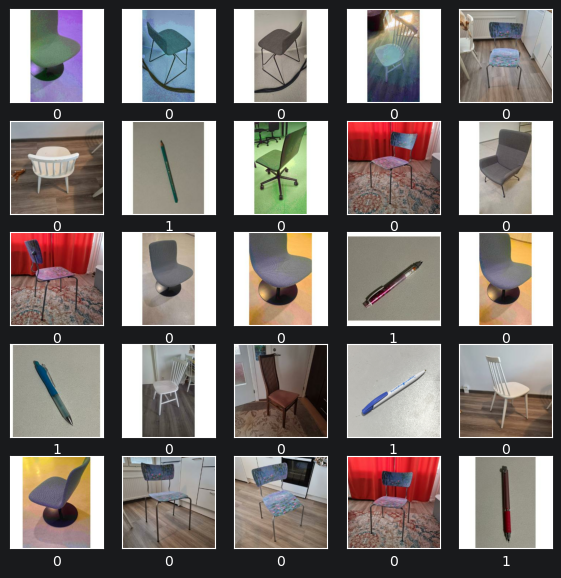

In [183]:
# use plt to visualize some of the images
plt.figure(figsize=(7, 7))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(y_train[i])
plt.show()

# Building and training our own convolutional neural network

Let's build our convolutional neural network from scratch using Keras. We will use data augmentation to help prevent overfitting, and we will also compute class weights to handle any class imbalance in our dataset.

In [184]:

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ]
)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)
class_weights_dict = dict(enumerate(class_weights))
print("Class weights:", class_weights_dict)

callbacks = [
    EarlyStopping(monitor="val_loss", patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=5, min_lr=1e-6),
]

Class weights: {0: 0.7289156626506024, 1: 1.5921052631578947}


In [185]:

model = models.Sequential([
    layers.Input(shape=(256, 256, 3)),
    data_augmentation,

    layers.Conv2D(16, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),

    layers.Conv2D(32, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),

    layers.Conv2D(64, 3, padding="same", activation="relu"),
    layers.MaxPooling2D(2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid"),
])

model.summary()

Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_30 (Sequential)      │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_45 (Conv2D)              │ (None, 256, 256, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_45 (MaxPooling2D) │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_46 (Conv2D)              │ (None, 128, 128, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_46 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_47 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_47 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_14     │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 27,809 (108.63 KB)

 Trainable params: 27,809 (108.63 KB)

 Non-trainable params: 0 (0.00 B)

In [186]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy", keras.metrics.AUC(name="auc")]
)

In [187]:
history = model.fit(
    x_train, y_train,
    epochs=50,
    batch_size=16,
    validation_data=(x_val, y_val),
    class_weight=class_weights_dict,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 450ms/step - accuracy: 0.3306 - auc: 0.3814 - loss: 0.7041 - val_accuracy: 0.3077 - val_auc: 0.8090 - val_loss: 0.7038 - learning_rate: 1.0000e-04
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 121ms/step - accuracy: 0.4215 - auc: 0.5390 - loss: 0.6932 - val_accuracy: 0.3077 - val_auc: 0.7326 - val_loss: 0.7040 - learning_rate: 1.0000e-04
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 105ms/step - accuracy: 0.3967 - auc: 0.5014 - loss: 0.6943 - val_accuracy: 0.3077 - val_auc: 0.8021 - val_loss: 0.7043 - learning_rate: 1.0000e-04
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.4298 - auc: 0.5796 - loss: 0.6896 - val_accuracy: 0.3077 - val_auc: 0.7743 - val_loss: 0.7060 - learning_rate: 1.0000e-04
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 119ms/step - accuracy: 0.4215 - auc: 0.6070 - loss: 0.6884 - val_accuracy: 0.3077 - val_auc: 0.8021 - val_loss: 0.7032 - learning_rate: 1.0000e-04
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 115ms/step - accuracy: 0.3967 - 

In [188]:

# Fixed-threshold evaluation setup (single rule: 0.50)
print("Class names:", dataset.class_names)
positive_class_name = dataset.class_names[1]
print("Positive class for binary metrics:", positive_class_name)

Class names: ['Chairs', 'Pens']
Positive class for binary metrics: Pens


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6667 - auc: 0.7862 - loss: 0.4678
Test loss: 0.4678
Test accuracy: 0.6667
Test AUC: 0.7862
class_names: ['Chairs', 'Pens']
train counts: [83 38]
val counts: [18  8]
test counts: [19  8]
Test precision (Pens): 0.4444
Test recall (Pens): 0.5000
Test F1 (Pens): 0.4706


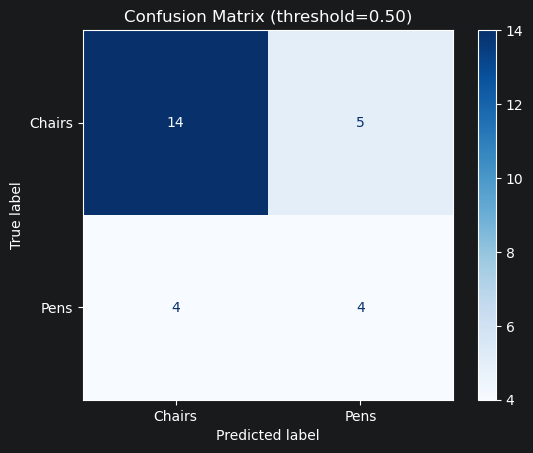

In [189]:
# Evaluate on test set (matches compile metrics: loss, accuracy, auc)
test_loss, test_acc, test_auc = model.evaluate(x_test, y_test, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# Predict probabilities and apply fixed threshold 0.50
y_pred_prob = model.predict(x_test, verbose=0).ravel()
print("class_names:", dataset.class_names)
print("train counts:", np.bincount(y_train))
print("val counts:", np.bincount(y_val))
print("test counts:", np.bincount(y_test))

y_pred = (y_pred_prob >= 0.5).astype(int)
p_test, r_test, f1_test, _ = precision_recall_fscore_support(
    y_test, y_pred, average="binary", zero_division=0
)

print(f"Test precision ({positive_class_name}): {p_test:.4f}")
print(f"Test recall ({positive_class_name}): {r_test:.4f}")
print(f"Test F1 ({positive_class_name}): {f1_test:.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=dataset.class_names)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix (threshold=0.50)")
plt.show()

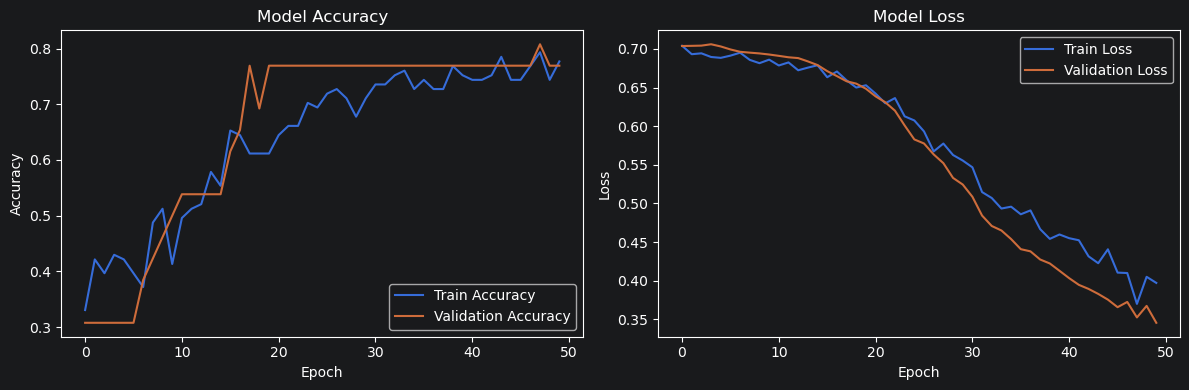

In [190]:
# Plot training & validation accuracy and loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()

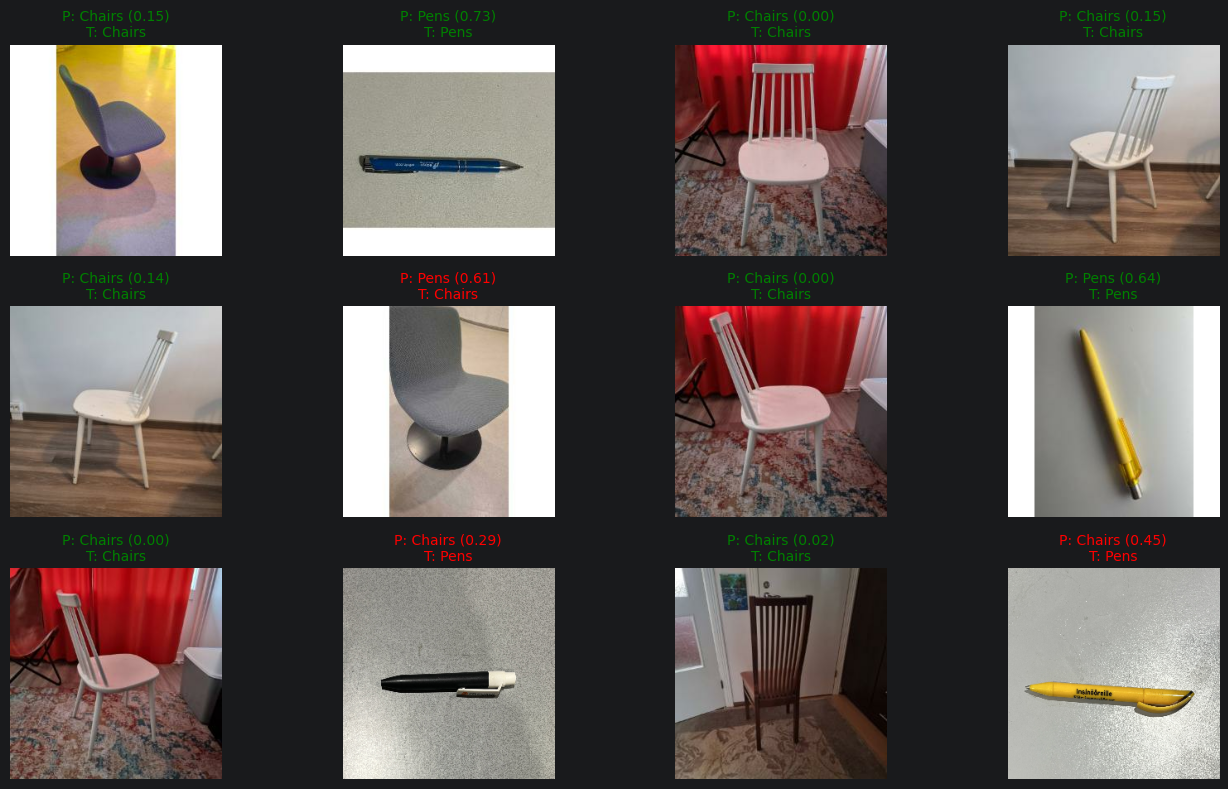

In [191]:
# Plot predictions: predicted vs actual labels for a few test images
num_images = 12
indices = rng.choice(len(x_test), size=min(num_images, len(x_test)), replace=False)

plt.figure(figsize=(14, 8))
for i, idx in enumerate(indices):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_test[idx])
    plt.axis("off")

    # Force scalar -> Python int for safe list indexing
    true_idx = int(np.asarray(y_test[idx]).squeeze())
    pred_idx = int(np.asarray(y_pred[idx]).squeeze())

    # y_pred_prob[idx] may be shape (1,), so squeeze first
    pred_prob = float(np.asarray(y_pred_prob[idx]).squeeze())

    true_label = dataset.class_names[true_idx]
    pred_label = dataset.class_names[pred_idx]

    color = "green" if true_idx == pred_idx else "red"
    plt.title(f"P: {pred_label} ({pred_prob:.2f})\nT: {true_label}", color=color, fontsize=10)

plt.tight_layout()
plt.show()
